In [1]:
import msprime
from demography import DemographicTopology
import numpy as np

[Event 1] Admixture: a -> aP1 & aP2
[Event 2] Merge: aP1 & aP2 -> aTop
[Event 3] Merge: aTop & b -> ab
[Event 4] Admixture: c -> cP1 & cP2
[Event 5] Merge: ab & cP1 -> left
[Event 6] Merge: d & cP2 -> right
[Event 7] Merge: left & right -> root
[Finalize] Set root time_end to infinity.


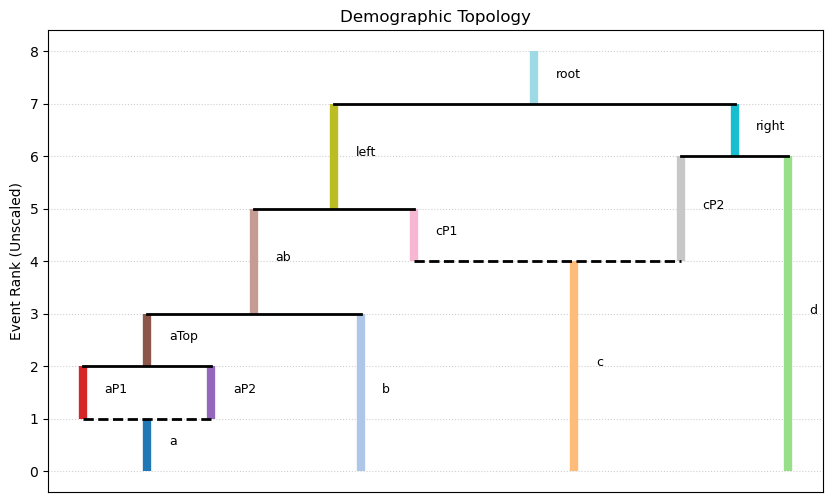

In [6]:
d = DemographicTopology(['a', 'b', 'c', 'd'])
# Loop on a
d.add_admixture_event('a', 'aP1', 'aP2')
d.add_merge_event('aP1', 'aP2', 'aTop')
# a-side joins b
d.add_merge_event('aTop', 'b', 'ab')
# Ancient admix on c
d.add_admixture_event('c', 'cP1', 'cP2')
# cP1 joins ab side; cP2 joins d side
d.add_merge_event('ab', 'cP1', 'left')
d.add_merge_event('d', 'cP2', 'right')
d.add_merge_event('left', 'right', 'root')

d.finalize_root()
d.plot_demography(scale = False)

[Event 1] Admixture: a -> aP1 & aP2
[Event 2] Merge: aP1 & aP2 -> aTop
[Event 3] Merge: aTop & b -> ab
[Event 4] Merge: ab & c -> abc
[Event 5] Merge: abc & d -> root
[Finalize] Set root time_end to infinity.


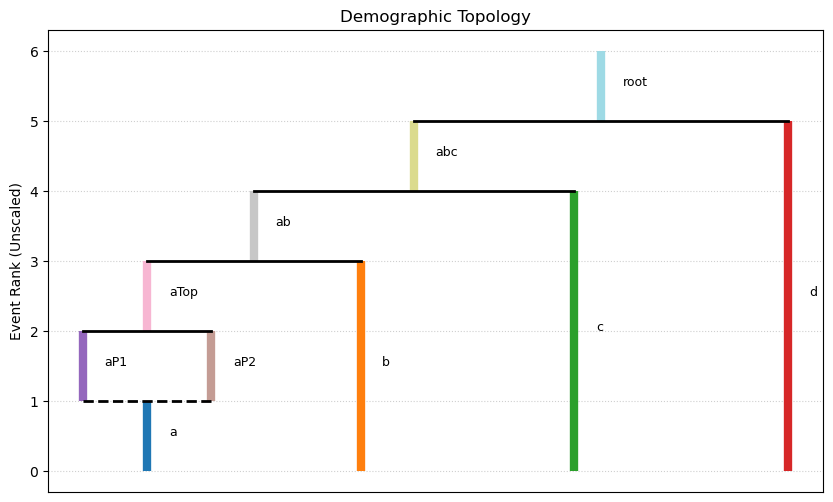

In [5]:
d = DemographicTopology(['a', 'b', 'c', 'd'])
d.add_admixture_event('a', 'aP1', 'aP2')
d.add_merge_event('aP1', 'aP2', 'aTop')
d.add_merge_event('aTop', 'b', 'ab')
d.add_merge_event('ab', 'c', 'abc')
d.add_merge_event('abc', 'd', 'root')
d.finalize_root()
d.plot_demography(scale = False)

[Event 1] Merge: a & b -> ab
[Event 2] Admixture: c -> cP1 & cP2
[Event 3] Merge: ab & cP1 -> left
[Event 4] Merge: d & cP2 -> right
[Event 5] Merge: left & right -> root
[Finalize] Set root time_end to infinity.


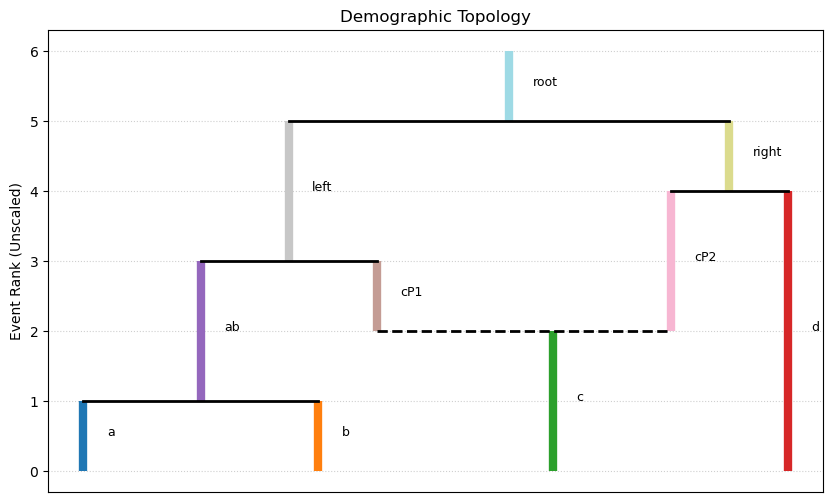

In [4]:
d = DemographicTopology(['a', 'b', 'c', 'd'])
d.add_merge_event('a', 'b', 'ab')
d.add_admixture_event('c', 'cP1', 'cP2')
d.add_merge_event('ab', 'cP1', 'left')
d.add_merge_event('d', 'cP2', 'right')
d.add_merge_event('left', 'right', 'root')
d.finalize_root()

d.plot_demography(scale = False)

In [7]:
# For simulation block, first translate to msprime format
from simulation_methods import to_msprime_demography

msp = to_msprime_demography(dem)
msp.debug()

In [10]:
# This block output the pruned snp frequencies table
from simulation_methods import simulate_msprime, simulate_snp_pruning, calculate_ibd_fractions_mrca

# recombination rate set to default 1e-8, thus sequence_length * recombination_rate gives the number of morgans.
mts = simulate_msprime(dem, 
                       sequence_length = 5e6, 
                       recombination_rate = 1e-7, 
                       mutation_rate = 1e-7,
                       samples_per_pop = {'a': 30, 'b': 20, 'c': 10, 'admix': 40})

ids, freq_array = simulate_snp_pruning(
    mts,
    dem,
    temporal_folder = './plink_output',
    cutoff_time = 1000
)


Running: plink --vcf plink_output/snp_ts.vcf --make-bed --out plink_output/snp_ts --double-id --allow-extra-chr --silent
Running: plink --bfile plink_output/snp_ts --indep-pairwise 100 5 0.2 --out plink_output/pruned --allow-extra-chr --silent
LD pruning complete. Kept 1520 SNPs.


In [11]:
bins = [[0.5,0.6],[0.6,0.7],[0.7,0.8],[0.8,0.9],[0.9,1.0],[1.0,1.5],[1.5,2],[2,5],[5,50]]
ibd_mean, ibd_sd = calculate_ibd_fractions_mrca(mts,bins = bins, cm_per_unit=1e-5, num_bootstraps = 2000)

Scanning trees for MRCA segments (19900 pairs)...


In [13]:
from simulation_methods import build_ibd_stan_data

stan_ibd = build_ibd_stan_data(dem, ibd_mean, ibd_sd, bins, T_max = 100000, cm=50)

[build_ibd_stan_data] Stan data assembled (corrected joint-path model):
  n_leaves     : 4
  n_nodes      : 10
  n_events     : 5
  n_admixture  : 1
  n_leaf_pairs : 10
  n_bins       : 9
  T_max        : 100000 generations
  ibd_hat      : [0.000e+00, 6.097e-03]
  ibd_se       : [1.000e-08,  1.398e-03]


In [21]:
from cmdstanpy import CmdStanModel

model = CmdStanModel(stan_file="ibd_model_Nfixed.stan")

init_dict = {
    "times": [100] * stan_ibd['n_events'],       # reasonable epoch durations
    "admixture_fractions": [0.5] * stan_ibd['n_admixture'],
    "effective_N": 10000.0
}

fit = model.pathfinder(
    data=stan_ibd,
    inits=init_dict,
    show_console=True
)

15:51:30 - cmdstanpy - INFO - Chain [1] start processing


Chain [1] method = pathfinder
Chain [1] pathfinder
Chain [1] init_alpha = 0.001 (Default)
Chain [1] tol_obj = 1e-12 (Default)
Chain [1] tol_rel_obj = 10000 (Default)
Chain [1] tol_grad = 1e-08 (Default)
Chain [1] tol_rel_grad = 1e+07 (Default)
Chain [1] tol_param = 1e-08 (Default)
Chain [1] history_size = 5 (Default)
Chain [1] num_psis_draws = 1000 (Default)
Chain [1] num_paths = 4 (Default)
Chain [1] save_single_paths = false (Default)
Chain [1] psis_resample = true (Default)
Chain [1] calculate_lp = true (Default)
Chain [1] max_lbfgs_iters = 1000 (Default)
Chain [1] num_draws = 1000 (Default)
Chain [1] num_elbo_draws = 25 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /var/folders/gm/vzcskl_s1wzfqy1p36xcp32h0000gn/T/tmp3x0egd7z/60l9z5ew.json
Chain [1] init = /var/folders/gm/vzcskl_s1wzfqy1p36xcp32h0000gn/T/tmp3x0egd7z/ro872a1f.json
Chain [1] random
Chain [1] seed = 45930
Chain [1] output
Chain [1] file = /var/folders/gm/vzcskl_s1wzfqy1p36xcp32h0000gn/T/tmp3x0egd

15:51:31 - cmdstanpy - INFO - Chain [1] done processing


Chain [1] Pareto k value (0.95) is greater than 0.7. Importance resampling was not able to improve the approximation, which may indicate that the approximation itself is poor.
Chain [1] 


In [72]:
from inference_methods import calculate_treemix_covariance

w_hat, w_se = calculate_treemix_covariance(
    freq_array,
    min_maf = 0.05,
    block_size_snps = 400
)